In [22]:
# ================================================
'''
1. 이진분류(Binary Classification) 실습
- 이진분류 모델 학습
- 학습 결과 저장
- 저장된 모델/스케일러/학습 이력 불러오기
- 신규 데이터 예측
- 학습결과 및 예측결과 시각화
'''
# ================================================

'\n1. 이진분류(Binary Classification) 실습\n- 이진분류 모델 학습\n- 학습 결과 저장\n- 저장된 모델/스케일러/학습 이력 불러오기\n- 신규 데이터 예측\n- 학습결과 및 예측결과 시각화\n'

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_breast_cancer       # 유방암 진단 데이터 셋 읽어오기
import joblib                                         # 파이썬 객체 저장을 위한 joblib

import tensorflow as tf                               # 딥러닝 프레임워크

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout               # 레이어 구성, 드롭아웃 적용 위한 라이브러리
from tensorflow.keras.callbacks import EarlyStopping             # 학습 조기종료 콜백 라이브러리

np.random.seed(42)
tf.random.set_seed(42)


In [5]:
# ================================================
# 1. 데이터 읽어오기
# ================================================

data = load_breast_cancer()
X = data.data      # 입력 x data
y = data.target    # 타겟 레이블 y 데이터 (예측하고자 하는 데이터의 정답 레이블)

feature_names = data.feature_names   # 특성 이름
df = pd.DataFrame(X, columns=feature_names)   # 데이터 확인을 위해 데이터프레임으로 변환

df['target'] = y 

print('전체 데이터 shape: ', df.shape)

전체 데이터 shape:  (569, 31)


In [6]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
# ================================================
# 2. 학습용/테스트용 데이터 분할  (학습데이터 80% / 테스트데이터 20%)
# ================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# ================================================
# 3. 스케일링
# ================================================
scaler = StandardScaler()                         # 스케일러 객체 생성
X_train_scaled = scaler.fit_transform(X_train)    # 학습 데이터 기준으로 평균과 표준편차를 학습하고 반환
X_test_scaled = scaler.transform(X_test)          # 테스트 데이터는 학습 데이터 기준으로 반환

In [9]:
# ================================================
# 4. 모델 정의
# ================================================
model = Sequential()               # 순차형 신경망 모델 생성

# 첫 번째 은닉층 추가
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))        # 과적합 방지를 위해 드롭아웃 20% 적용

# 두 번째 은닉층 추가
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# 출력층 
model.add(Dense(1, activation='sigmoid'))   # 이진분류 모델(0 or 1)이므로 출력 수만큼 뉴런을 구성

# 모델 구조 출력
model.summary()  



D:\miniconda3\envs\ai\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ================================================
# 5. 모델 컴파일 설정
# ================================================

model.compile(
    optimizer='adam',             # 학습은 adam 적용
    loss='binary_crossentropy',   # 손실함수는 binary_crossentropy 적용
    metrics=['accuracy']          # 평가지표는 accuracy 사용
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
    monitor='val_loss',       # val_loss 값이 더이상 줄어들지 않고 계속 같은 값이 나온다면 학습 종료
    patience=10,
    restore_best_weights=True
)

In [11]:
# ================================================
# 6. 모델 학습
# ================================================

# 모델을 학습하고, history 객체에 학습 과정을 저장  
history = model.fit(
    X_train_scaled,            # 입력 데이터 x
    y_train,                   # 정답 데이터 y  
    validation_split=0.2,      # 검증 20%  
    epochs=100,                # 전체 학습 수 100번
    batch_size=32,             # 학습 1회 사이클 32번
    callbacks=[early_stop],    # 조기종료 콜백 정의
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6593 - loss: 0.6246 - val_accuracy: 0.8571 - val_loss: 0.4680
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8352 - loss: 0.4068 - val_accuracy: 0.9231 - val_loss: 0.3233
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9093 - loss: 0.2980 - val_accuracy: 0.9341 - val_loss: 0.2434
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9341 - loss: 0.2339 - val_accuracy: 0.9341 - val_loss: 0.1952
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9396 - loss: 0.1902 - val_accuracy: 0.9451 - val_loss: 0.1616
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.1591 - val_accuracy: 0.9560 - val_loss: 0.1367
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9588 - loss: 0.1358 - val_accuracy: 0.9560 - val_loss: 0.1150
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9615 - loss: 0.1205 - val_accuracy: 0.9670

In [12]:
# ================================================
# 7. 모델 평가
# ================================================

# 테스트 데이터(20%)에 대해 손실과 정확도를 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

# 평가 결과 출력
print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 확률을 0 또는 1 클래스로 변환
y_pred = (y_prob >= 0.5).astype(int).flatten()  

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도: ', acc)
print('confusion matirix: \n', cm)
print('분류 리포트: \n', classification_report(y_test, y_pred))


테스트 손실:  0.09608259797096252
테스트 정확도:  0.9649122953414917
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
정확도:  0.9649122807017544
confusion matirix: 
 [[41  1]
 [ 3 69]]
분류 리포트: 
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [13]:
# ================================================
# 8. 학습결과 저장
# ================================================

# 모델을 파일로 저장
model.save('./model/Binary_Classification.h5')   # 또는 Binary_Classification.keras

# 스케일러를 파일로 저장
joblib.dump(scaler, './model/Binary_Classification.pkl')

# 학습이력을 데이터 프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv 파일로 저장
history_df.to_csv('./model/Binary_Classification.csv', index=False)

print("이진분류 모델, 스케일러, 학습이력 저장 완료")

이진분류 모델, 스케일러, 학습이력 저장 완료


In [14]:
history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.659341,0.624614,0.857143,0.467977
1,0.835165,0.406849,0.923077,0.323284
2,0.909341,0.298045,0.934066,0.243393
3,0.934066,0.233864,0.934066,0.195163
4,0.939560,0.190156,0.945055,0.161609


In [15]:
# ================================================
# 9. 저장된 결과 읽어 오기
# ================================================

# 저장된 모델을 다시 읽어오기
loaded_model = tf.keras.models.load_model('./model/Binary_Classification.h5')

# 저장된 스케일러를 다시 읽어오기
loaded_scaler = joblib.load('./model/Binary_Classification.pkl')

In [16]:
# ================================================
# 10. 신규 데이터 예측
# ================================================

# 학습하지 않은 테스터데이터 중 5개를 신규 데이터로 예측 수행
new_data = X_test[:5]

# 신규 데이터 스케일링 처리
new_data_scaled = loaded_scaler.transform(new_data)

# 신규 데이터 예측 확률 계산
new_prob = loaded_model.predict(new_data_scaled)

# 예측 확률값을 0 or 1로 변환
new_pred = (new_prob >= 0.5).astype(int).flatten()

# 결과 출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측확률: {new_prob[i][0]:.4f}, 예측클래스: {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1번 샘플 - 예측확률: 0.0000, 예측클래스: 0
2번 샘플 - 예측확률: 1.0000, 예측클래스: 1
3번 샘플 - 예측확률: 0.0000, 예측클래스: 0
4번 샘플 - 예측확률: 0.3158, 예측클래스: 0
5번 샘플 - 예측확률: 0.0000, 예측클래스: 0


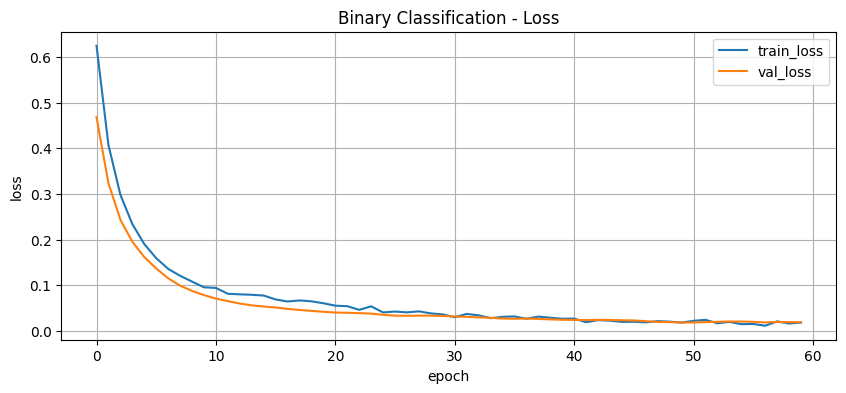

In [17]:
# ================================================
# 11. 시각화 결과 확인
# ================================================

# 학습, loss 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary Classification - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)  # 그래프 격자 표시
plt.show()

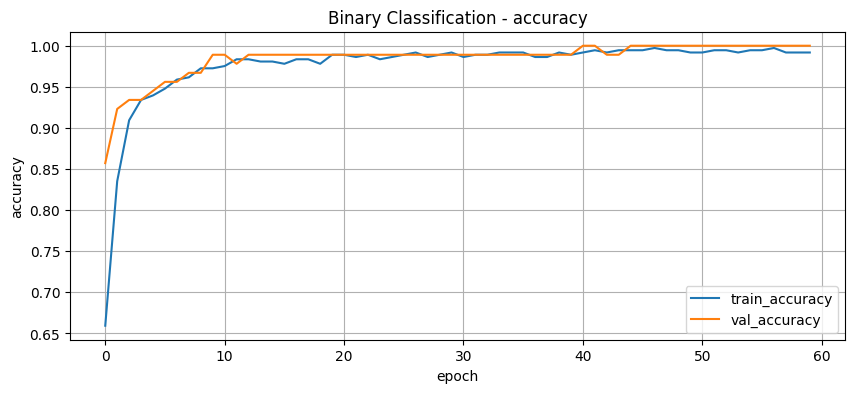

In [18]:
# 학습, 정확도 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Binary Classification - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)  # 그래프 격자 표시
plt.show()

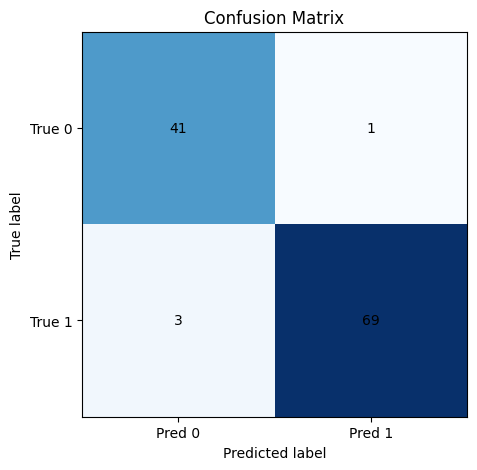

In [20]:
# confusion matrix 시각화
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')

# x축과 y축 눈금 설정
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])

# cm 내부에 숫자 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

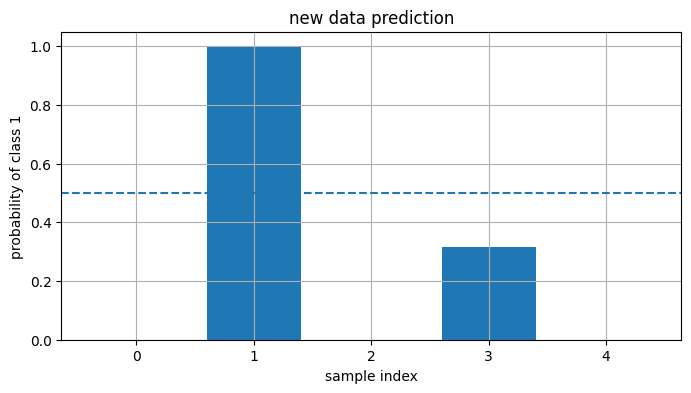

In [21]:
# 신규 데이터 예측 결과 시각화
new_prob_flat = new_prob.flatten()

plt.figure(figsize=(8,4))
plt.bar(range(len(new_prob_flat)), new_prob_flat)

# 기준선 0.5 표시
plt.axhline(0.5, linestyle="--")

plt.title('new data prediction')
plt.xlabel('sample index')
plt.ylabel('probability of class 1')

plt.grid(True)
plt.show()